#PCA (Principal Component Analysis):


1.PCA (Principal Component Analysis) is a technique in Machine Learning and Data Science that reduces the number of features while keeping as much important information as possible.

2.By projecting a high-dimensional dataset into a smaller feature space, PCA also minimizes, or altogether eliminates, common issues such as multicollinearity and overfitting. Multicollinearity occurs when two or more independent variables are highly correlated with one another, which can be problematic for causal modeling. Overfit models will generalize poorly to new data,

3.PCA is a dimension reduction technique like linear discriminant analysis (LDA). In contrast to LDA, PCA is not limited to supervised learning tasks. For unsupervised learning tasks, this means PCA can reduce dimensions without having to consider class labels or categories.

4.PCA and k-means clustering are both unsupervised machine learning techniques used for data analysis, but they have different goals and methods. PCA is used to reduce the dimensionality of the data, while k-means clustering groups data points together based on similarity. The technique you select depends on the specific dataset and goals of your analysis.

5.PCA creates new variables, such as principal components, that are linear combinations of the original variables.




#Calculating principal components1. Scaling (Standardization)

1. Convert all features to same scale (mean = 0, variance = 1)

2. Compute Covariance Matrix
   Measure how features vary and relate to each other

3. Calculate Eigenvalues & Eigenvectors
   Eigenvalues → importance (variance)
   Eigenvectors → directions (principal components)

4. Select Top Components
   Choose top eigenvalues that explain required variance (e.g., 90–95%)

5. Transform Data
   Multiply original data with selected eigenvectors to get principal components

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
columns = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",

    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",

    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

In [3]:
df= pd.read_csv('/content/wdbc.data',names=columns)

In [4]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
df.shape

(569, 32)

In [6]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave_points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [8]:
df['diagnosis'].value_counts(normalize=True)

,proportion
diagnosis,
B,0.627417
M,0.372583


In [9]:
df.isnull().any().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop('id', axis=1,inplace=True)

In [12]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [13]:
x=df.drop('diagnosis',axis=1)
y=df['diagnosis']

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
print(x_train.shape,y_train.shape)
print(x_test.shape,y_test.shape)

(455, 30) (455,)
(114, 30) (114,)


In [16]:
from sklearn.preprocessing import StandardScaler
scalar= StandardScaler()

In [17]:
x_train_scaled=scalar.fit_transform(x_train)
x_test_scaled=scalar.transform(x_test)

#Logistric Accuarcy before PCA

In [19]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression()
lg.fit(x_train_scaled,y_train)

LogisticRegression()

In [21]:
y_predict_lg_before =lg.predict(x_test_scaled)

In [23]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [24]:
accuracy_score(y_test,y_predict_lg_before)

0.9736842105263158

In [55]:
confusion_matrix(y_test,y_predict_lg_before)

array([[70,  1],
       [ 2, 41]])

In [56]:
report_before = classification_report(y_test, y_predict_lg_before, output_dict=True)
df_before = pd.DataFrame(report_before).transpose()
print("Before PCA")
display(df_before.round(3))

Before PCA


,precision,recall,f1-score,support
B,0.972,0.986,0.979,71.000
M,0.976,0.953,0.965,43.000
accuracy,0.974,0.974,0.974,0.974
macro avg,0.974,0.970,0.972,114.000
weighted avg,0.974,0.974,0.974,114.000


#Principal Component Analysis

In [30]:
from sklearn.decomposition import PCA
pca= PCA(n_components=0.95)


In [31]:
x_train_pca=pca.fit_transform(x_train_scaled)
x_test_pca=pca.transform(x_test_scaled)

In [32]:
print(x_train_pca.shape,x_test_pca.shape)

(455, 10) (114, 10)


In [33]:
pca.explained_variance_ratio_

array([0.43502782, 0.19500007, 0.09781519, 0.06486409, 0.05253378,
       0.041128  , 0.0223559 , 0.01647952, 0.01380052, 0.01205262])

#Accuracy of LOgistric Regression after PCA

In [34]:
lg.fit(x_train_pca,y_train)

LogisticRegression()

In [36]:
y_predict_lg_after=lg.predict(x_test_pca)

In [37]:
accuracy_score(y_test,y_predict_lg_after)

0.9824561403508771

In [39]:
confusion_matrix(y_test,y_predict_lg_after)

array([[70,  1],
       [ 1, 42]])

In [57]:
report_after = classification_report(y_test, y_predict_lg_after, output_dict=True)
df_after = pd.DataFrame(report_after).transpose()
print("After PCA")
display(df_after.round(3))

After PCA


,precision,recall,f1-score,support
B,0.986,0.986,0.986,71.000
M,0.977,0.977,0.977,43.000
accuracy,0.982,0.982,0.982,0.982
macro avg,0.981,0.981,0.981,114.000
weighted avg,0.982,0.982,0.982,114.000


#LinearDecriminativeAnalysis

In [45]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda=LinearDiscriminantAnalysis()

In [85]:
x_train_lda = lda.fit_transform(x_train_scaled,y_train)
x_test_lda = lda.transform(x_test_scaled)

In [86]:
lg.fit(x_train_lda,y_train)

LogisticRegression()

In [87]:
y_predict_lda=lg.predict(x_test_lda)

In [88]:
accuracy_score(y_test,y_predict_lda)

0.9473684210526315

In [89]:
confusion_matrix(y_test,y_predict_lda)

array([[67,  4],
       [ 2, 41]])

In [90]:
report_lda = classification_report(y_test, y_predict_lda, output_dict=True)
df_lda = pd.DataFrame(report_lda).transpose()
print("LDA")
display(df_lda.round(3))

LDA


,precision,recall,f1-score,support
B,0.971,0.944,0.957,71.000
M,0.911,0.953,0.932,43.000
accuracy,0.947,0.947,0.947,0.947
macro avg,0.941,0.949,0.944,114.000
weighted avg,0.948,0.947,0.948,114.000


#Desicion Tree beofre PCA

In [59]:
from sklearn.tree import DecisionTreeClassifier

In [60]:
dc=DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=0)

In [61]:
dc.fit(x_train_scaled,y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [62]:
y_predict_dc_before_pca=dc.predict(x_test_scaled)

In [63]:
accuracy_score(y_test,y_predict_dc_before_pca)


0.9385964912280702

In [65]:
confusion_matrix(y_test,y_predict_dc_before_pca)

array([[68,  3],
       [ 4, 39]])

In [67]:
report_DT=classification_report(y_test,y_predict_dc_before_pca,output_dict=True)
df_DT=pd.DataFrame(report_DT).transpose()
print("Decision Tree")
display(df_DT.round(3))



Decision Tree


,precision,recall,f1-score,support
B,0.944,0.958,0.951,71.000
M,0.929,0.907,0.918,43.000
accuracy,0.939,0.939,0.939,0.939
macro avg,0.937,0.932,0.934,114.000
weighted avg,0.938,0.939,0.938,114.000


#Decision Tree after PCA:

In [139]:
dc_after=DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=0)

In [140]:
dc_after.fit(x_train_pca,y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [141]:
y_predict_dt_after_pca=dc_after.predict(x_test_pca)

In [142]:
accuracy_score(y_test,y_predict_dt_after_pca)

0.956140350877193

In [143]:
confusion_matrix(y_test,y_predict_dt_after_pca)

array([[68,  3],
       [ 2, 41]])

In [144]:
dc_lda=DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=0)

In [145]:
dc_lda.fit(x_train_lda,y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [146]:
y_predict_dc_lda=dc_lda.predict(x_test_lda)

In [147]:
accuracy_score(y_test,y_predict_dc_lda)

0.9385964912280702

In [148]:
confusion_matrix(y_test,y_predict_dc_lda)

array([[65,  6],
       [ 1, 42]])

#Random Forest before PCA:

In [72]:
from sklearn.ensemble import RandomForestClassifier

In [94]:
rf_before=RandomForestClassifier()

In [95]:
rf_before.fit(x_train_scaled,y_train)

RandomForestClassifier()

In [97]:
y_test_RF_before_pca=rf_before.predict(x_test_scaled)

In [98]:
accuracy_score(y_test,y_test_RF_before_pca)

0.956140350877193

In [100]:
confusion_matrix(y_test,y_test_RF_before_pca)

array([[69,  2],
       [ 3, 40]])

In [101]:
rf2=RandomForestClassifier(n_estimators=100,max_depth=7,random_state=42)
rf2.fit(x_train_scaled,y_train)

RandomForestClassifier(max_depth=7, random_state=42)

In [102]:
y_test_RF_before_pca2=rf2.predict(x_test_scaled)

In [104]:
accuracy_score(y_test,y_test_RF_before_pca2)

0.9649122807017544

In [149]:
confusion_matrix(y_test,y_test_RF_before_pca2)

array([[70,  1],
       [ 3, 40]])

* The accuracy of the base Random Forest model before PCA is 0.956

* The accuracy of the tuned Random Forest model before PCA is also 0.964




#LDA

In [112]:
rf_LDA= RandomForestClassifier()


In [113]:
rf_LDA.fit(x_train_lda,y_train)

RandomForestClassifier()

In [114]:
y_predict_rf_lda=rf_LDA.predict(x_test_lda)

In [115]:
accuracy_score(y_test,y_predict_rf_lda)

0.9473684210526315

In [116]:
confusion_matrix(y_test,y_predict_rf_lda)

array([[67,  4],
       [ 2, 41]])

#Random Forest after PCA:

##base model

In [118]:
rf_after=RandomForestClassifier()

In [119]:
rf_after.fit(x_train_pca,y_train)

RandomForestClassifier()

In [120]:
y_test_RF_after_pca=rf_after.predict(x_test_pca)

In [121]:
accuracy_score(y_test,y_test_RF_after_pca)

0.9473684210526315

##tuning model model

In [122]:
rf_after2=RandomForestClassifier(max_depth=3, random_state=42,)

In [123]:
rf_after2.fit(x_train_pca,y_train)

RandomForestClassifier(max_depth=3, random_state=42)

In [124]:
y_test2_RF_after_pca=rf_after2.predict(x_test_pca)

In [125]:
accuracy_score(y_test,y_test2_RF_after_pca)

0.9298245614035088

In [127]:
confusion_matrix(y_test,y_test2_RF_after_pca)

array([[68,  3],
       [ 5, 38]])

In [128]:
rf_after3= RandomForestClassifier(max_depth=9,n_estimators=180, random_state=42)

In [129]:
rf_after3.fit(x_train_pca,y_train)

RandomForestClassifier(max_depth=9, n_estimators=180, random_state=42)

In [131]:
y_test3_RF_after_pca=rf_after3.predict(x_test_pca)

In [132]:
accuracy_score(y_test,y_test3_RF_after_pca)

0.9473684210526315

In [133]:
confusion_matrix(y_test,y_test3_RF_after_pca)

array([[68,  3],
       [ 3, 40]])

In [134]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7, None],
    'criterion': ['gini', 'entropy']
}

rf_grid = RandomForestClassifier(random_state=42)

grid = GridSearchCV(estimator=rf_grid, param_grid=param_grid, cv=5)

grid.fit(x_train_pca, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, None],
                         'n_estimators': [100, 200]})

In [135]:
y_predict_grid=grid.predict(x_test_pca)

In [136]:
accuracy_score(y_test,y_predict_grid)

0.9473684210526315

In [137]:
confusion_matrix(y_test,y_predict_grid)

array([[68,  3],
       [ 3, 40]])

In [154]:
import pandas as pd

data = {
    "model": [
        "Logistic", "Logistic", "Logistic",
        "Decision Tree", "Decision Tree", "Decision Tree",
        "Random Forest", "Random Forest", "Random Forest"
    ],
    "accuracy": [
        0.9737, 0.9824, 0.9474,
        0.9386, 0.9561, 0.9386,
        0.9649, 0.9474, 0.9474
    ],
    "method": [
        "Before PCA", "After PCA", "LDA",
        "Before PCA", "After PCA", "LDA",
        "Before PCA", "After PCA", "LDA"
    ]
}

df = pd.DataFrame(data)
df

,model,accuracy,method
0,Logistic,0.9737,Before PCA
1,Logistic,0.9824,After PCA
2,Logistic,0.9474,LDA
3,Decision Tree,0.9386,Before PCA
4,Decision Tree,0.9561,After PCA
5,Decision Tree,0.9386,LDA
6,Random Forest,0.9649,Before PCA
7,Random Forest,0.9474,After PCA
8,Random Forest,0.9474,LDA


In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

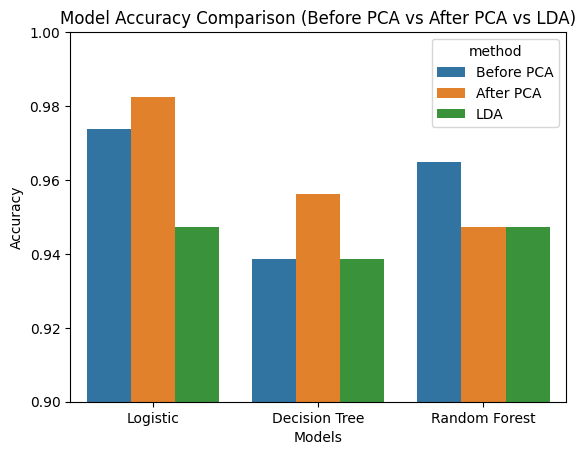

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.barplot(data=df, x="model", y="accuracy", hue="method")

plt.title("Model Accuracy Comparison (Before PCA vs After PCA vs LDA)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)

plt.show()


# 📊 Model Performance Summary

## 🔹 Logistic Regression

* Before PCA: Accuracy = **97.37%**, False Negatives = 2
* After PCA ✅ (Best Model): Accuracy = **98.25%**, False Negatives = 1
* LDA ❌: Accuracy = **94.74%**, performance dropped

---

## 🔹 Decision Tree

* Before PCA: Accuracy = **93.86%**
* After PCA ✅: Accuracy = **95.61%**, improved recall
* LDA ❌: No improvement

---

## 🔹 Random Forest

* Before PCA ✅ (Best for RF): Accuracy = **96.49%**
* After PCA ❌: Accuracy = **94.74%**, performance dropped
* LDA ❌: Similar drop

---

## 🧠 Key Insights

* PCA improved Logistic Regression and Decision Tree
* PCA reduced performance of Random Forest
* LDA performed worse due to excessive dimensionality reduction

---

## 🚨 Medical Insight (Important)

Minimizing **False Negatives** (missed malignant cases) is critical.
Logistic Regression + PCA reduced false negatives → most reliable model

---

## ✅ Final Conclusion

Logistic Regression with PCA achieved the best performance (**98.25%**) and is the most suitable model for this dataset.
